In [1]:
import pandas as pd

df = pd.read_excel("BD/06_MATRICULAS_ED_SUPERIOR_VALPARAISO_2021.xlsx")

df

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,10,Femenino,24,20 a 24,2016,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Salud,10,0,10,130000,3713000,Valparaiso,Valparaiso,Vina Del Mar
1,25,Femenino,19,15 a 19,2021,Primer semestre,Institutos Profesionales,IP INSTITUTO DE ESTUDIOS BANCARIOS GUILLERMO S...,ACREDITADA,17/12/2017 AL 17/12/2022,...,Carreras Profesionales,Administracion y Comercio,8,0,8,190000,1900000,Valparaiso,Valparaiso,Vina Del Mar
2,28,Masculino,24,20 a 24,2019,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Profesionales,Administracion y Comercio,8,1,8,190000,1760000,Valparaiso,San Felipe De Aconcagua,San Felipe
3,29,Masculino,24,20 a 24,2015,Primer semestre,Universidades CRUCH,PONTIFICIA UNIVERSIDAD CATOLICA DE VALPARAISO,ACREDITADA,26/11/2015 AL 26/11/2021,...,Carreras Profesionales,Educacion,9,0,9,208000,2558000,Valparaiso,Valparaiso,Valparaiso
4,42,Masculino,26,25 a 29,2014,Primer semestre,Universidades CRUCH,UNIVERSIDAD TECNICA FEDERICO SANTA MARIA,ACREDITADA,29/12/2016 AL 29/12/2022,...,Carreras Profesionales,Arte y Arquitectura,10,1,11,186000,4350000,Valparaiso,Valparaiso,Valparaiso
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109193,1048489,Masculino,40,40 y mas,2015,Segundo semestre,Universidades Privadas,UNIVERSIDAD DE LAS AMERICAS,ACREDITADA,17/03/2019 AL 17/03/2023,...,Carreras Profesionales,Ciencias Sociales,11,0,11,170000,4000000,Valparaiso,Valparaiso,Vina Del Mar
109194,1048493,Masculino,23,20 a 24,2021,Primer semestre,Institutos Profesionales,IP DUOC UC,ACREDITADA,26/08/2017 AL 26/08/2024,...,Carreras Tecnicas,Ciencias Basicas,5,1,5,176000,2060000,Valparaiso,Valparaiso,Valparaiso
109195,1048494,Masculino,23,20 a 24,2017,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE PLAYA ANCHA DE CIENCIAS DE LA E...,ACREDITADA,27/09/2016 AL 27/09/2021,...,Carreras Profesionales,Educacion,9,1,9,152000,2465000,Valparaiso,Valparaiso,Valparaiso
109196,1048503,Masculino,35,35 a 39,2020,Primer semestre,Institutos Profesionales,IP AIEP,ACREDITADA,22/10/2017 AL 22/10/2022,...,Carreras Tecnicas,Administracion y Comercio,5,1,5,190000,1880000,Valparaiso,San Antonio,San Antonio


In [2]:
import pandas as pd

# Agrupar por área y calcular estadísticas
costo_por_area = (
    df.groupby("AREA CONOCIMIENTO")[["VALOR ARANCEL (PESOS)", "VALOR MATRICULA (PESOS)"]]
    .mean()
    .sort_values("VALOR ARANCEL (PESOS)", ascending=False)
    .round(0)
)

print(costo_por_area)

                           VALOR ARANCEL (PESOS)  VALOR MATRICULA (PESOS)
AREA CONOCIMIENTO                                                        
Derecho                                4085330.0                 285941.0
Salud                                  3661373.0                 241707.0
Agropecuaria                           3347222.0                 206473.0
Arte y Arquitectura                    3245624.0                 209382.0
Ciencias Basicas                       3236685.0                 218013.0
Tecnologia                             3179646.0                 209720.0
Ciencias Sociales                      3025849.0                 220110.0
Humanidades                            2890243.0                 173774.0
Administracion y Comercio              2788276.0                 224284.0
Educacion                              2232336.0                 182837.0


In [4]:
costo_por_area = (
    df.groupby("AREA CONOCIMIENTO")["VALOR ARANCEL (PESOS)"]
    .agg(["mean","median","std"])
    .round(0)
)

print(costo_por_area)

                                mean     median        std
AREA CONOCIMIENTO                                         
Administracion y Comercio  2788276.0  2380000.0  1161323.0
Agropecuaria               3347222.0  4003610.0  1254749.0
Arte y Arquitectura        3245624.0  3141500.0   896082.0
Ciencias Basicas           3236685.0  3320000.0   847132.0
Ciencias Sociales          3025849.0  2830000.0  1177994.0
Derecho                    4085330.0  4350000.0   800099.0
Educacion                  2232336.0  2465000.0   581521.0
Humanidades                2890243.0  2994000.0   571489.0
Salud                      3661373.0  3685340.0  1560688.0
Tecnologia                 3179646.0  3038000.0  1199012.0


In [5]:
costo_area = df.groupby("AREA CONOCIMIENTO")["VALOR ARANCEL (PESOS)"].agg(["mean","std"]).round(0)
costo_area["CV_%"] = (costo_area["std"] / costo_area["mean"] * 100).round(2)
costo_area = costo_area.sort_values("mean", ascending=False)
print(costo_area)

                                mean        std   CV_%
AREA CONOCIMIENTO                                     
Derecho                    4085330.0   800099.0  19.58
Salud                      3661373.0  1560688.0  42.63
Agropecuaria               3347222.0  1254749.0  37.49
Arte y Arquitectura        3245624.0   896082.0  27.61
Ciencias Basicas           3236685.0   847132.0  26.17
Tecnologia                 3179646.0  1199012.0  37.71
Ciencias Sociales          3025849.0  1177994.0  38.93
Humanidades                2890243.0   571489.0  19.77
Administracion y Comercio  2788276.0  1161323.0  41.65
Educacion                  2232336.0   581521.0  26.05


Para determinar en qué áreas del conocimiento las carreras son más caras, se utilizó el valor del arancel promedio y mediano por área.

Dado que los datos presentan asimetrías (la media y la mediana difieren significativamente), se consideró la mediana como el indicador más representativo del costo típico, ya que reduce el efecto de valores extremos.

/var/folders/_d/bcbtk5vn291fk9tnt4fkrlj80000gn/T/ipykernel_6420/1694414933.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


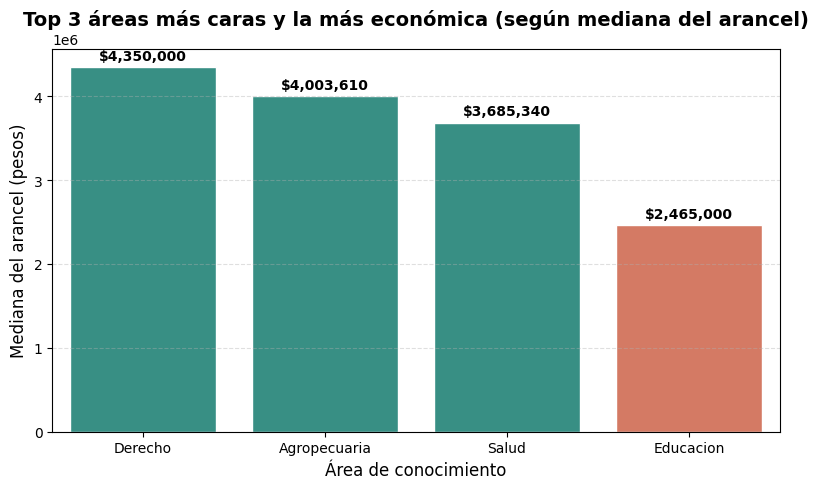

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

datos = {
    "AREA CONOCIMIENTO": ["Derecho", "Agropecuaria", "Salud", "Educacion"],
    "Mediana Arancel": [4350000, 4003610, 3685340, 2465000]
}
df_top = pd.DataFrame(datos)

df_top = df_top.sort_values("Mediana Arancel", ascending=False)

colores = ["#2a9d8f" if area != "Educacion" else "#e76f51" for area in df_top["AREA CONOCIMIENTO"]]

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_top,
    x="AREA CONOCIMIENTO",
    y="Mediana Arancel",
    palette=colores,
    edgecolor="white"
)

for i, valor in enumerate(df_top["Mediana Arancel"]):
    plt.text(i, valor + 50000, f"${valor:,.0f}", ha="center", va="bottom", fontsize=10, weight="bold")

plt.title("Top 3 áreas más caras y la más económica (según mediana del arancel)", fontsize=14, weight="bold")
plt.xlabel("Área de conocimiento", fontsize=12)
plt.ylabel("Mediana del arancel (pesos)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()